In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
e0 = 8.854187817e-12  # Vacuum permittivity (F/m)
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(e0 * mu0)
dt = 0.18e-9
dx = vp * dt

nx = 401
nt = 401
L = (nx - 1) * dx
T = (nt - 1) * dt

t = np.arange(0, T, dt)
xgrid = np.linspace(0, L, nx) - L / 2

# campos
Ez = np.zeros((nt, nx))
Hy = np.zeros((nt, nx))

# no ponto central, aplica uma fonte senoidal
f0 = 278e6  # Frequência da fonte (Hz)
Ez[:, nx // 2] = np.sin(2 * np.pi * f0 * np.arange(nt) * dt)

# marcha no tempo
for n in range(1, nt - 1):

    # --- Update H at half step (stored at n+1) ---
    for i in range(1, nx - 1):
        Hy[n+1, i] = Hy[n, i] + (dt / (mu0 * dx)) * (Ez[n, i+1] - Ez[n, i])

    # --- Update E at next step ---
    for i in range(1, nx - 1):
        Ez[n+1, i] = Ez[n, i] + (dt / (e0 * dx)) * (Hy[n+1, i] - Hy[n+1, i-1])

    # Boundary conditions (simple) - zero volts at the boundaries
    Ez[n+1, 0] = 0
    Ez[n+1, -1] = 0



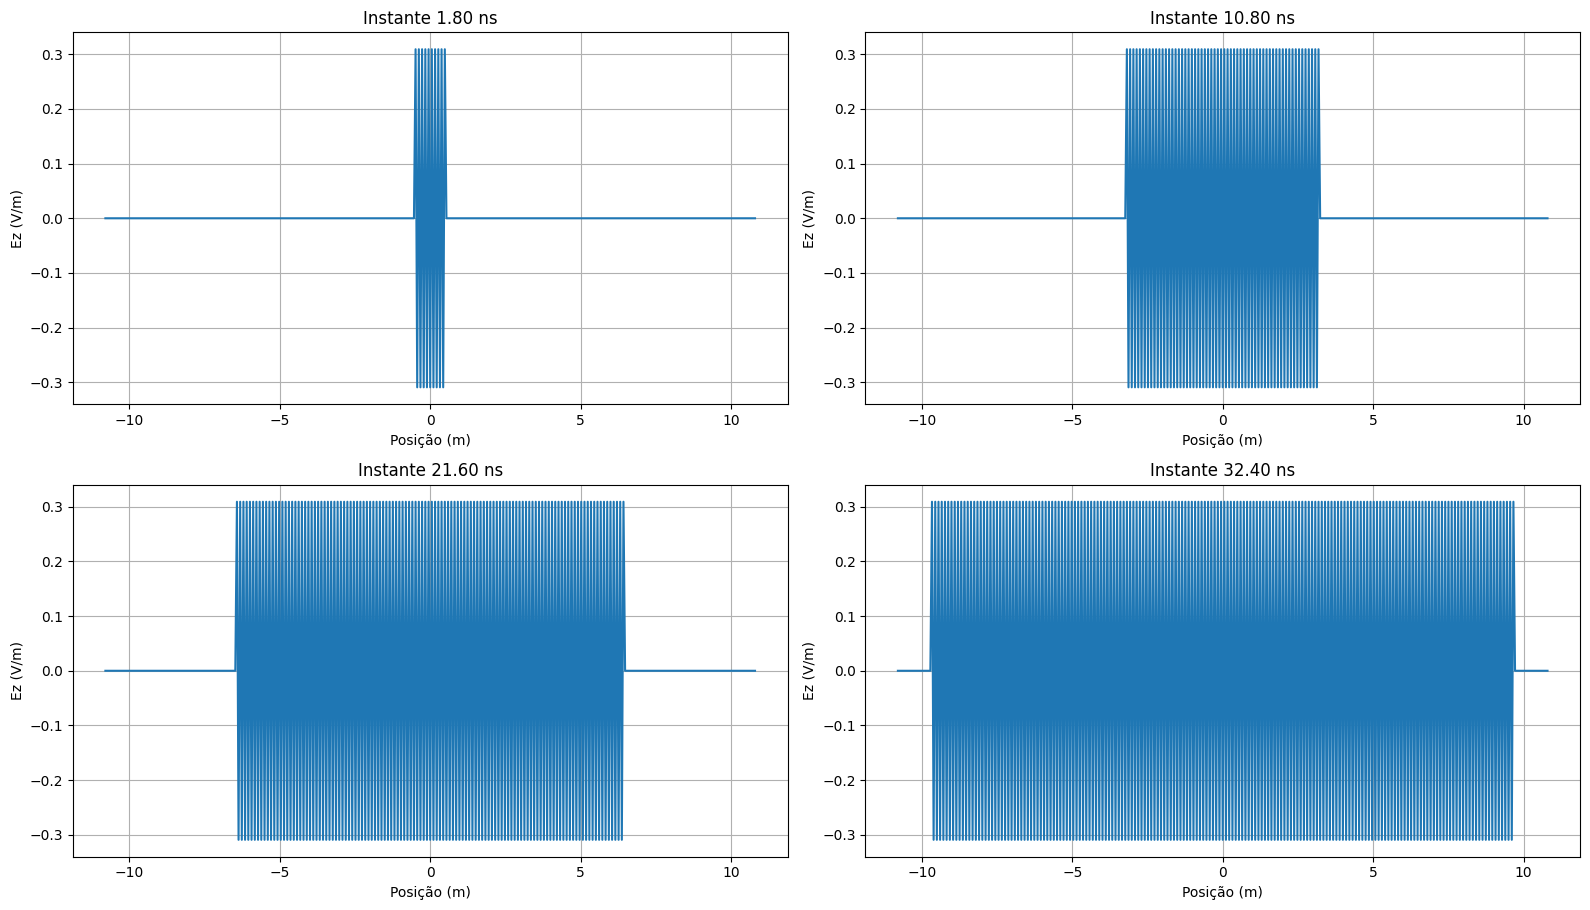

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# Plot a few time snapshots
t_list = [10, 60, 120, 180]

for k, ax in enumerate(axes.flatten()):
    ax.plot(xgrid, Ez[t_list[k], :], label=f"t = {t_list[k]*dt*1e9:.2f} ns")
    ax.set_title(f'Instante {t_list[k] * dt * 1e9:.2f} ns')      # Set a title for each subplot
    ax.set_xlabel('Posição (m)')
    ax.set_ylabel('Ez (V/m)')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

plt.show()